<div style="text-align: right;">
    

## FIT 1043 Introduction to Data Science 
### Assignment Task A2 
#### Name: Daffa Fariq Prasetyo
#### Student ID: 34076492

*** 
</div>

## 1. Introduction
The goal of this report is to offer a clear, organized, analytical, and conducting machine learning from the data supplied by Spotify. The list that contained the characteristics of the songs and their genre of music was used as the foundation for the dataset. Exploratory analysis was carried out utilizing data such as artist name, track name, popularity, and others to seek out connected data and investigate machine learning using libraries that were accessible to build different models, output the results, and get the results to be independently reviewed.  

<b> A brief summary of steps for the assingment:</b>
1. Import the data
2. Split the Data into training and testing sets.
3. Normalizing the data
4. Create a model
5. Train the model
6. Make predictions
7. Evaluate and Imporve 

***

## Part A: Classification 
<b> A1.1. explain supervised machine learning, the notion of labelled data, and train and test datasets. </b>

### Answer
<b> Supervised learning </b> in simple terms is like teaching a robot by showing it examples and telling it what's right. It is when the algorithm learns from labeled data, meaning each examples in the training data has an input and output pair. 

<b> Labelled data </b> In supervised learning, these labeles represent the correct output corresponding to the input data. It is like giving names to things. For example, if theres a picture of a dog, we tell the robot, "This is a dog." 

<b> Training Dataset </b> is used to train the machine learning model. It consists of input-output pairs (features and lables) that the model learns from. In simple terms, the programmer shows it alot of labeled pictures of animals and tells it which animal is.

<b> Test Dataset </b> is used to evaluate the performance of the trained model. It contains examples with inputs but without its corresponding labels. The model's predictions are compared to the true lables. Essentialy, showing the model a picture of an animal it hasn't seen before and asking it to guess what animal it is and then we check if its right.


Investigate the data 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#check which headings are texts
music_data = pd.read_csv('FIT1043-MusicGenre-Dataset.csv')
music_data.shape
music_data.head()

,instance_id,artist_name,track_name,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,music_genre
0,77382,Sheena Ringo,獣ゆく細道,48,0.01340,0.423,224053,0.799,0.000004,0.1470,-4.227,0.0447,124.626,0.5560,1
1,23554,empty_field,Fossil Roo,22,0.86200,0.590,151067,0.221,0.468000,0.0736,-16.338,0.0383,129.984,0.0331,1
2,82886,The Beatles,Dear Prudence - 2018 Mix,62,0.09040,0.395,234973,0.538,0.000453,0.0685,-10.300,0.0456,150.785,0.3690,9
3,37772,Pink Floyd,Have a Cigar,64,0.40700,0.454,307733,0.650,0.049800,0.5890,-10.191,0.0437,120.154,0.7200,9
4,80191,A-Trak,Push,43,0.00145,0.642,213512,0.877,0.002790,0.0984,-2.878,0.0450,126.058,0.4960,5


From the dataset above, we can see that there are columns or data that includes texts, which is something that can't be used in the algorithms. So, we will drop these two columns of artist_name and track_name.

<b> A1.2) Separating the features and the labels. </b>

In [2]:
import pandas as pd

#Droping 'track_name' and 'artist_name' 
filtered_data = music_data.drop(columns=['track_name', 'artist_name'])

#Features are the input variables and labels are the output variable
#Drop'music_genre' column to keep only features and make 'music_genre' the label
features = filtered_data.drop(columns=['music_genre'])
label = filtered_data['music_genre']

<b> A1.3) splitting the data into training and testing data </b>

In [3]:
from sklearn.model_selection import train_test_split 

#splitting the data into training and testing sets with the test size being 20%
X_train, x_test, Y_train, y_test = train_test_split(features, label, test_size=0.2, random_state=42)

#outputing the head
filtered_data.head()

,instance_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,music_genre
0,77382,48,0.01340,0.423,224053,0.799,0.000004,0.1470,-4.227,0.0447,124.626,0.5560,1
1,23554,22,0.86200,0.590,151067,0.221,0.468000,0.0736,-16.338,0.0383,129.984,0.0331,1
2,82886,62,0.09040,0.395,234973,0.538,0.000453,0.0685,-10.300,0.0456,150.785,0.3690,9
3,37772,64,0.40700,0.454,307733,0.650,0.049800,0.5890,-10.191,0.0437,120.154,0.7200,9
4,80191,43,0.00145,0.642,213512,0.877,0.002790,0.0984,-2.878,0.0450,126.058,0.4960,5


***

<b> A2.1) Differences between binary and multi-class classification </b>

Binary classification and multi-class classification are the two primary types of tasks in supervised machine learning. Binary classification requires separating between two distinct classes, such as spam emails and non-spam emails. The most common methods include logistic regression and support vector machines (SVM). 

Multi-class classification, on the other hand, involves separating between three or more classes, such as car types or animal classification. Algorithms such as logistics regression using softmax or neural networks are often used.
 
The distinctions between the two are based on the number of classes, output representation, algorithm complexity, and evaluation criteria. Binary classification works with two classes, but multi-class classification handles multiple classes, gives a vector result, and may require a more complicated method.

<b> A2.2) normalizing/scaling data </br>
a) What i understand from this need to normalise data


Normalizing data is critical for machine learning tasks, especially when dealing with features that have different scales, which are usually between 0 and 1 or within a specific range.  By doing so, you prevent features with larger scales from dominating the learning algorithm and ensure that the model lerans from each feature equally. For example, changing a material's difficulty such that it is suitable for everyone. This guarantees that they are on similar scales and that certain features do not dominate the learning process for everyone. 

<b> Appropriate normalisation functions to scale the data </b> 

Using the MinMaxScaler

In [4]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

#Fit or scale the training features
X_train_scaled = scaler.fit_transform(X_train)

#Transform the testing features using the fitted scaler
X_test_scaled = scaler.transform(x_test)

***

<b> A2.3 SVM algorithm </b>

<b> A) Describing SVM </b> <br>
The main objective of SVM is to the find the hyperplan that best separtes the classes in the feature, input, space. its as if there is two groups of points on a graph and you want to draw a line that separates them as best as possible. It finds the best line or curve to split theg groups while keeping as much space as possible between them. The space is like a safety zone to help classify new points correctly. SVM aims to find this line (or curve) in a way that minimizes mistakes and works well even when the groups overlap. 

<b> B) What is a kernel </b> <br>The kernel in SVM helps in the discovery of patterns in data that would otherwise be difficult to detect. Visualize data as dots in space. Sometimes drawing a straight line to break these dots into groups is ineffective because they are all mixed up. That is where the kernel comes in. SVM adapts to varied datasets by using kernels such as linear, polynomial, RBF, and sigmoid. It decodes complex relationships well. As a result, the kernel functions as SVM's superpower, helping it in solving complex data problems. .

In [5]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

#Create the svm classifier using the rbf kernel
svm_classifier = SVC(kernel='rbf', random_state=42) 

#Train the SVM classifier using the scaled training data
svm_classifier.fit(X_train_scaled, Y_train)

#Predict the labels for the scaled testing data
y_pred_svm = svm_classifier.predict(X_test_scaled)

<b> Why did i choose the RBF kernel? </b><br>
out of all the other kernels, linear, polynomial, sigmoid and RBF, the one with the highest accuracy is the RBF kernel of 54.16% 

<b> A2.4 </b> 
For this classification algorithm, I would use the Random Forest algorithm, which is an ensemble learning method that generates numerous decision trees during training and then combines their predictions to increase accuracy and prevent overfitting.

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

#Random Forest classifier
rf_classifier = RandomForestClassifier(random_state=42)

#Train the Random Forest Classifier 
rf_classifier.fit(X_train, Y_train)

#Predict the labels for the scaled testing data 
y_pred_rf = rf_classifier.predict(x_test)

***
<b> A.3) Classification (prediction) <b>

<b> A.3.1) Predicition for music_genre

In [7]:
from sklearn.metrics import accuracy_score, precision_score, f1_score

#Accuracy for SVM
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print("Accuracy (SVM):", accuracy_svm)

#Precision for SVM
precision_svm = precision_score(y_test, y_pred_svm, average='weighted')
print("Precision (SVM):", precision_svm)

#F1-score for SVM
f1_svm = f1_score(y_test, y_pred_svm, average='weighted')
print("F1-score (SVM):", f1_svm)

#Accuracy for Random Forest
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Accuracy (Random Forest):", accuracy_rf)

#Precision for Random Forest
precision_rf = precision_score(y_test, y_pred_rf, average='weighted')
print("Precision (Random Forest):", precision_rf)

#F1-score for Random Forest
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')
print("F1-score (Random Forest):", f1_rf)


Accuracy (SVM): 0.5416024653312789
Precision (SVM): 0.5416173742406744
F1-score (SVM): 0.5363292575726708
Accuracy (Random Forest): 0.5614406779661016
Precision (Random Forest): 0.5639093923169621
F1-score (Random Forest): 0.5600384970348948


<b> A.3.2)  Display the confusion matrices for both models  </b>

To determine the accuracy of the two algorithm; the SVM method using the rbf kernel and the Random Forest algorithm, we compare the y_pred with the actual y_test by viewing it using a confusion matrix.

In [8]:
X_train.head()

,instance_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
2878,36634,74,0.391,0.693,173947,0.464,0.000000,0.1570,-7.912,0.2240,78.100,0.868
5140,49714,33,0.291,0.492,329567,0.411,0.000000,0.1030,-9.528,0.0267,143.939,0.213
8944,24992,53,0.224,0.547,276016,0.732,0.000001,0.3340,-7.205,0.3790,78.978,0.163
1272,45892,57,0.148,0.701,462267,0.788,0.625000,0.0977,-5.611,0.0425,142.584,0.795
20100,45522,38,0.169,0.587,223533,0.800,0.000000,0.1790,-5.688,0.0365,106.007,0.411


*****
<b> This is the confusion matrix for the SVM classifier


In [9]:
from sklearn.metrics import confusion_matrix

#Calculate confusion matrix for SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)
print("Confusion Matrix (SVM):")
print(cm_svm)

Confusion Matrix (SVM):
[[185   0  10   0 113  31  55  31  16 103]
 [ 21 308  38  58  18  21   0   9   0   4]
 [ 22  49 281   4  80  31   1  55   0  24]
 [ 13  16  10 425   4  11   0  15   0   1]
 [ 32  15  47   0 271  11  16  44   4  90]
 [ 39  24  35   6  32 302  17  48   8  19]
 [ 19   0   1   0  16   7 321   2 141  35]
 [ 15   9  74  36  44  64  12 210   1  20]
 [ 26   0   2   0  16   4 257   0 141  61]
 [ 60   2   2   0  44   4  13  19  23 368]]


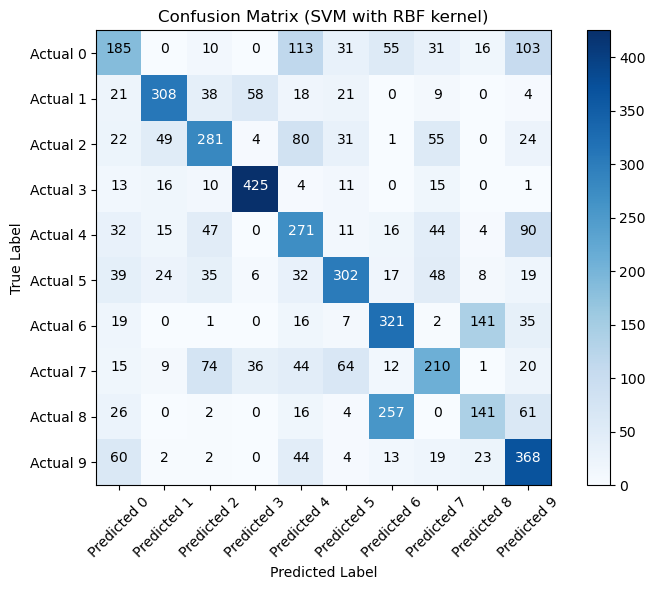

In [10]:
from sklearn.metrics import confusion_matrix
from sklearn.utils.multiclass import unique_labels

#Now we'll use the confusion matrix and mix it with a heatmap. 

#Function to create the confusion matrix DataFrame
def plot(y_true, y_pred):
    labels = unique_labels(y_true)
    columns = [f'Predicted {label}' for label in labels]
    index = [f'Actual {label}' for label in labels]
    cm = confusion_matrix(y_true, y_pred)
    return pd.DataFrame(cm, columns=columns, index=index)

#Generate confusion matrix DataFrame
cm_df = plot(y_test, y_pred_svm)

#Plot confusion matrix as heatmap
plt.figure(figsize=(8, 6))
plt.imshow(cm_df, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix (SVM with RBF kernel)')
plt.colorbar()
tick_marks = range(len(cm_df.columns))
plt.xticks(tick_marks, cm_df.columns, rotation=45)
plt.yticks(tick_marks, cm_df.index)
fmt = 'd'
thresh = cm_df.values.max() / 2.
for i in range(cm_df.shape[0]):
    for j in range(cm_df.shape[1]):
        plt.text(j, i, format(cm_df.values[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm_df.values[i, j] > thresh else "black")


plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()


*****
 <b> This is the confusion matrix for the Random Forest classifier

In [11]:
from sklearn.metrics import confusion_matrix

#Calculate confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix (Random Forest):")
print(cm_rf)

Confusion Matrix (Random Forest):
[[191   5  10   1  74  27  51  34  30 121]
 [ 17 355  28  32  11  22   0   9   0   3]
 [ 28  35 306   5  58  33   2  56   1  23]
 [ 11  14  15 423   3   8   0  19   0   2]
 [ 37   8  24   0 318   5   9  26   7  96]
 [ 40  20  37   8  20 305   9  59  11  21]
 [ 24   1   1   0   4   5 259   1 225  22]
 [ 12   4  64  36  33  65   9 234   2  26]
 [ 23   1   1   0   6   1 250   2 169  54]
 [ 59   5   6   1  52   1  23  11  22 355]]


using a heat map to display the confusion matrix for better understanding. 

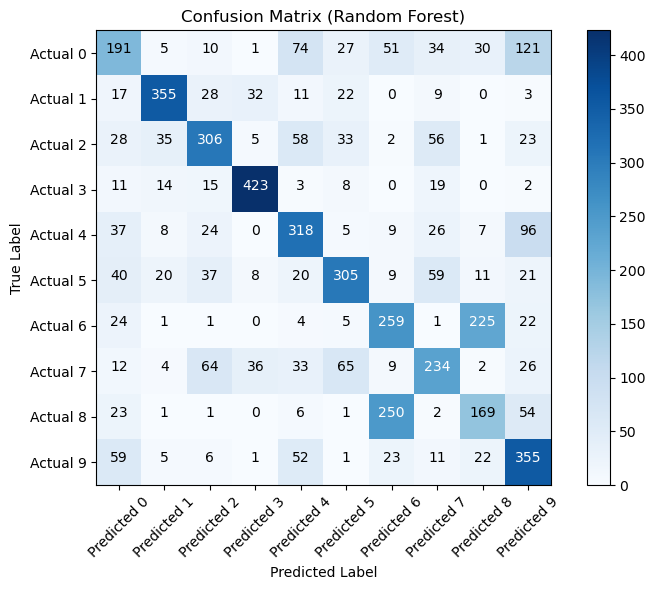

In [12]:
#Function to create the confusion matrix DataFrame
def plot(y_true, y_pred):
    labels = unique_labels(y_true)
    columns = [f'Predicted {label}' for label in labels]
    index = [f'Actual {label}' for label in labels]
    cm = confusion_matrix(y_true, y_pred_rf)
    return pd.DataFrame(cm, columns=columns, index=index)

#Generate confusion matrix DataFrame
cm_df = plot(y_test, y_pred_rf)

#Plot confusion matrix as heatmap
plt.figure(figsize=(8, 6))
plt.imshow(cm_df, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix (Random Forest)')
plt.colorbar()
tick_marks = range(len(cm_df.columns))
plt.xticks(tick_marks, cm_df.columns, rotation=45)
plt.yticks(tick_marks, cm_df.index)
fmt = 'd'
thresh = cm_df.values.max() / 2.
for i in range(cm_df.shape[0]):
    for j in range(cm_df.shape[1]):
        plt.text(j, i, format(cm_df.values[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm_df.values[i, j] > thresh else "black")

plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()


### Evaluation) 
##### Data found 
<b> SVM: </b>
<br> Accuracy: 0.542 
<br> Precision: 0.542
<br> F1-score: 0.536
<br> <b> Random Forest: </b>
<br> Accuracy: 0.561
<br> Precision: 0.564
<br> F1-score: 0.560
***
After evaluating the performance of both Support Vector Machine (SVM) and Random Forest classifiers, it is observed that the Random Forest classifier outperforms SVM in terms of accuracy, precision, and F1-score. The Random Forest classifier achieved an accuracy of approximately 56.1%, precision of 56.4%, and F1-score of 56.0%, while the SVM classifier achieved slightly lower metrics with an accuracy of about 54.2%, precision of 54.2%, and F1-score of 53.6%. <br>
The Random Forest classifier's higher accuracy indicates that it correctly classified a higher proportion of instances compared to SVM. Additionally, its higher precision and F1-score suggest that it achieved better balance between correctly identifying positive instances and minimizing false positives.
<br>
##### Heatmap 
By visualizing both the classifier into a heatmap, we can see a diagonal line that has an increase of the colours intensity and each of them reflects the number of instances classified into the specific category, aiding us in seeing the classifier's performance accross different classes. <br> 
comparing them side by side we can see that the random forest classifier exhibits a stronger diagonal elemtns by showing a higher colour intensity compared to the svm. Additionaly, there are areas in the svm  heatmap where off-diagonal elements are more pronounced, such as the predicted 5 and the actual 8 as well as the predicted 7 and the actual 6, suggesting higher rates of misclassifications compared to Random Forest. <br> 
In conclusion, we can see that the heatmap analysis helps us see that using the random forest classifier is far more suitable for this data set as it outperforms the SVM. 

***** 
<b> A4. Independent Evaluation </b> 

In [13]:
import pandas as pd 
from sklearn.ensemble import RandomForestClassifier

#Step 1: Loading the data 
rf_music_data = pd.read_csv('FIT1043-MusicGenre-Submission.csv')

#Step 2: Preprocess the data
columns_to_drop = ['artist_name', 'track_name']
filtered_rf_data = rf_music_data.drop(columns=columns_to_drop)


#Step 5: Making predictions 
predictions = rf_classifier.predict(filtered_rf_data)  # Use rf_features instead of features

#Step 6: Create a DataFrame containing 'instance_id' and predicted 'music_genre'
output_df = pd.DataFrame({
    'instance_id': rf_music_data['instance_id'],
    'music_genre': predictions
})

#Step 7: Save the predictions to a CSV file
output_df.to_csv('34076492-DaffaPrasetyo_v1.csv', index=False)
print("Predictions saved to 34076492-DaffaPrasetyo_v1.csv")
print(output_df.shape)

Predictions saved to 34076492-DaffaPrasetyo_v1.csv
(6490, 2)


***

<div style="text-align: right;">
    

## FIT 1043 Introduction to Data Science 
### Assignment 2 Task B
#### Name: Daffa Fariq Prasetyo
#### Student ID: 34076492

*** 
</div>

## Introduction 
dataset used from kaggle: https://www.kaggle.com/datasets/jaceprater/smokers-health-data <br>
The goal of this report is to offer a clear and organized research of the smokers health data provided by kaggle. We are to perform a k-means clustering algorithm instead of the other classifier as it is an unsupervised machine learning algorithm or instances. I have documented the steps by steps of how i removed the non-numerical data as well as made some data such as the sex and the cigs_per_day transform from non-numerical data to numerical data and applying the k-means clustering to the age and the cigs_per_day variables to see how age effects the cigs_per_day. 
***

<b> The first step is to import the data and to analyse the findings

In [15]:
import pandas as pd 
smoking_data = pd.read_csv('smoking_health_data_final.csv')

#investigate the data
smoking_data.shape
smoking_data.head()

,age,sex,current_smoker,heart_rate,blood_pressure,cigs_per_day,chol
0,54,male,yes,95,110/72,NaN,219.0
1,45,male,yes,64,121/72,NaN,248.0
2,58,male,yes,81,127.5/76,NaN,235.0
3,42,male,yes,90,122.5/80,NaN,225.0
4,42,male,yes,62,119/80,NaN,226.0


Here we can see that the sex and the current_smokers are both non numerical so we have to perform some functions to convert it to numerical values.

In [16]:
#Changing the non numerical values to numerical values

#1 representing the Male, Yes
#0 representing the Female, No

smoking_DF = pd.DataFrame(smoking_data)
gender_mapping = {'male': 1, 'female': 0}
smoking_DF['sex'] = smoking_DF['sex'].map(gender_mapping)

smoker_mapping = {'yes':1, 'no':0}
smoking_DF['current_smoker'] = smoking_DF['current_smoker'].map(smoker_mapping)

#Removing the non-numerical values from the table
smoking_DF.drop(columns=['blood_pressure'], inplace=True)

<B> here we check how many null values there are in the data set of both cigs_per_day and the chol variables  

In [17]:
#here we can see how many values are null, or the missing values 
print(smoking_DF['cigs_per_day'].isnull().sum())
print(smoking_DF['chol'].isnull().sum())

14
7


In [18]:
#Input missing values in 'cigs_per_day' column with the median value.
median_cigs_per_day = smoking_DF['cigs_per_day'].median()
smoking_DF['cigs_per_day'] = smoking_DF['cigs_per_day'].fillna(median_cigs_per_day)

#Input missing values in 'chol' column with the median values.
median_chol = smoking_DF['chol'].median()
smoking_DF['chol'] = smoking_DF['chol'].fillna(median_chol)

#Now we check if there are any more null values
print(smoking_DF['cigs_per_day'].isnull().sum())
print(smoking_DF['chol'].isnull().sum())

smoking_DF.head()

0
0


,age,sex,current_smoker,heart_rate,cigs_per_day,chol
0,54,1,1,95,0.0,219.0
1,45,1,1,64,0.0,248.0
2,58,1,1,81,0.0,235.0
3,42,1,1,90,0.0,225.0
4,42,1,1,62,0.0,226.0


In [19]:
#Input missing values in 'chol' column with median
median_chol = smoking_DF['chol'].median()
smoking_DF['chol'] = smoking_DF['chol'].fillna(median_chol)

#Verify that missing values have been handled
print(smoking_DF['chol'].isnull().sum())

smoking_DF.head()

0


,age,sex,current_smoker,heart_rate,cigs_per_day,chol
0,54,1,1,95,0.0,219.0
1,45,1,1,64,0.0,248.0
2,58,1,1,81,0.0,235.0
3,42,1,1,90,0.0,225.0
4,42,1,1,62,0.0,226.0


***
<B> Visualisation of the variables Age and the cigs_per_day

Text(0, 0.5, 'Cigs_Per_Day_Features')

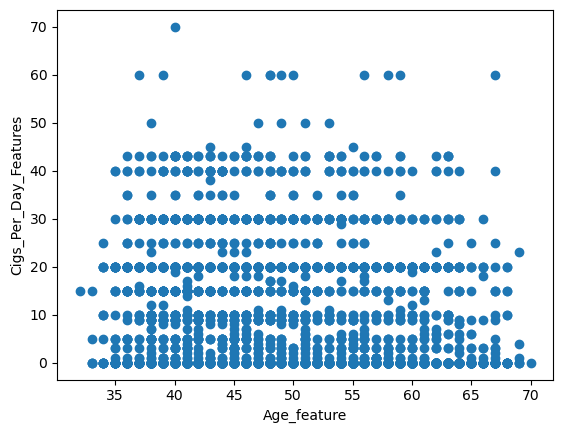

In [20]:
import matplotlib.pyplot as plt
%matplotlib inline 

#visualise the dataset (Age vs cigs_per_day)
plt.scatter(x=smoking_DF['age'], y=smoking_DF['cigs_per_day'])
plt.xlabel('Age_feature')
plt.ylabel('Cigs_Per_Day_Features')

***
<B> Now we implement the k-means cluster between 2 and 4 to see which is better suited for this dataset 

C:\Users\daffa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


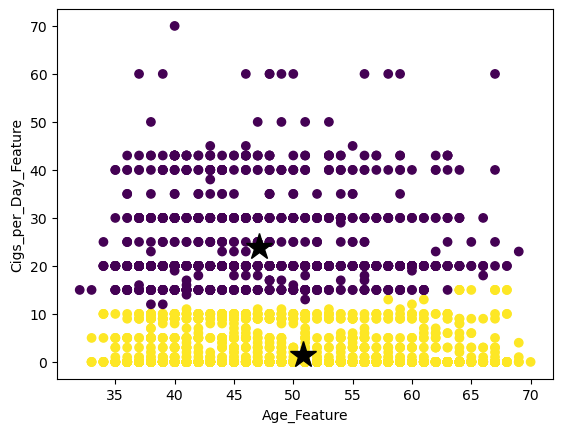

In [21]:
from sklearn.cluster import KMeans

#Apply KMeans clustering of k=2
kmeans = KMeans(n_clusters=2, init='random').fit(
    smoking_DF[['age','cigs_per_day']]
        )

#Visualize the cluster
plt.scatter(
    x = smoking_DF['age'],
    y = smoking_DF['cigs_per_day'],
    c=kmeans.labels_)

#Visualise the clustercenters
plt.plot( 
kmeans.cluster_centers_[:,0], 
kmeans.cluster_centers_[:,1], 
'k*', 
markersize=20 
) 

plt.xlabel('Age_Feature') 
plt.ylabel('Cigs_per_Day_Feature') 
plt.show() 

C:\Users\daffa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


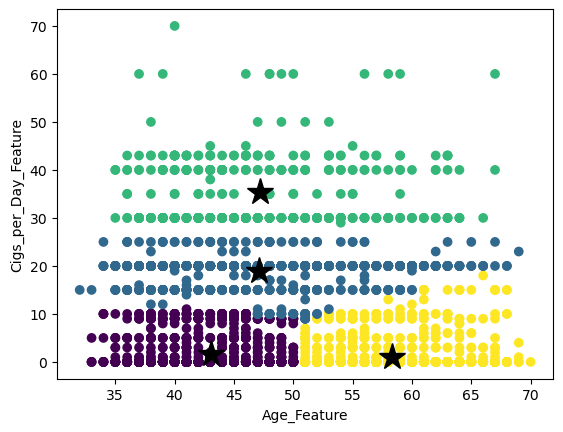

In [22]:
#Apply KMeans clustering of k =4
kmeans = KMeans(n_clusters=4, init='random').fit(
    smoking_DF[['age','cigs_per_day']]
        )

#Visiualise the clusters
plt.scatter(
    x = smoking_DF['age'],
    y = smoking_DF['cigs_per_day'],
    c=kmeans.labels_)

#Visualise the clustercenters
plt.plot( 
kmeans.cluster_centers_[:,0], 
kmeans.cluster_centers_[:,1], 
'k*', 
markersize=20 
) 

plt.xlabel('Age_Feature') 
plt.ylabel('Cigs_per_Day_Feature') 
plt.show()

***
<B> Analysis

<b> scatter diagram </b> <br>
From the original data, in the scatterplot we can see that the relation between the Age and the ciggaretes per day are distributed quite spreadout with the majority of the ciggarates consumption per day being less than 30 per day, which is still quite high. Before the clustering even began, the cigs per day tend to lean between 10 to 20 per day but it varies to 60 per day with 1 being an exception of having 70 per day. Though it is obvious that there is no trend and that age does not effect the amount of ciggaretes smoked per day.

<b> clusters with 2 groups </b> <br> <br>
<b> Differences </b> <br> 
<b>cluster 1 </b> = This cluster includes the clusters with the ages that smokes less than or equal to 15 ciggaretes consumption <br>
<b>cluster 2 </b> = This cluster shows the ciggarete consumption of more than 15 but it does not show that age effects the ciggarete consumption. What it does show is that, it varies from people to people and there are some people that smoke more than 60 per day.

<b> patterns </b> <br> 
1. there is a clear separation between the ages that smokes less than 15 cigarettes per day and the one with more than 15 cigs consumption
2. this segmentation suggest that there are pindividuals that are highly addicted to ciggaretes regardless of their age. tures = 

<b> clusters with 4 groups </b> <br> <br>
<b> Differences </b>  <br> 
<b>cluster 1 </b> = This cluster shows the individuals that smokes the minimal and is below the age of 50  <br>
<b>cluster 2 </b> = This consists of older people with still minimal ciggarette consumpiton   <br>
<b>cluster 3 </b> = this inludes the whole generation that smokes intermediately which is around 15 - 25 cigs consumption  <br>
<b>cluster 4 </b> = These are the individuals that no matter the age, they are heavy smokers and smoke between 30- to 60 ciggs per day with one having 70 cigs per day<br> 

<b>Emphasis on well-defined clusters</b> <br> 
1. cluster 3 and cluster 4 stand out as they are well defined and homogeneous with clear intent that age does not correlate with the amount of ciggaretes are being consumed on a daily, which is what we can see nowaydays that every single teen are getting into smoking, wether it be vapes or sheesha, anything of that matter.
2. cluster 4 appears to be the most extreme in terms of addiction for smoking or ciggarette in particular and is quite worrying as they are heavy smokers and varies in their age
   

<b> Comparision between the two clusterings: </b> <br> 
- in the clustering with 2 groups, the segmentation primarily revolves around the cigs consumption on a daily and is not effected by the age.
- It is also solidified on the clusterings with 4 groups, as it just shows which one of the individuals are heavy smokers, light smokers (still not light as it is 10 cigs per day) and the moderate smokers.
- while the clustering with 2 groups offers a simplified view of the data, the clusterings with 4 groups provides a more specific insights of the type of smokers the individuals are regardless of their age. This data considsts of middle ages man and women to old women and old men.
- overall, the clustering with 4 groups offers a more richer, indepth understanding of the data, looking at finer variation between the light, moderate and heavy smokers compared to the clustring with 2 groups 

### This ends my evaluation, I hope you had a great time reading this discovery and report.  